## LiDAR — per-parcel height extraction (pdal-free)

Workflow for a single AIN — no pdal, no las env required:
1. Look up parcel geometry → WGS84 bbox with buffer
2. Discover USGS 3DEP tiles via TNM REST API → download LAZ via HTTP
3. Load with laspy, build bare-earth DTM from class-2 points using scipy
4. Filter point cloud to parcel footprint
5. Compute nDSM = z − DTM → building height metrics + visualisation

In [1]:
import os, sys
os.environ["PROJ_DATA"] = "/Users/adamswietek/opt/anaconda3/envs/openview/share/proj"
os.environ["PROJ_LIB"]  = os.environ["PROJ_DATA"]

In [2]:
import os
os.chdir('../..')

import numpy as np
import geopandas as gpd
import requests
import laspy
from pathlib import Path
from scipy.interpolate import LinearNDInterpolator
from shapely import contains_xy

from src.geoadmin import load_parcels_by_AIN, get_landbase_bymask

MASTER_PATH = 'data/processed/assessor_lariac.gpkg'
LIDAR_ROOT  = Path('data/02_interm/lidar')
BUFFER_DEG  = 0.0003        # ~30 m padding around parcel in WGS84
NATIVE_CRS  = 'EPSG:2229'   # LA county State Plane (stored in GPKG)
UTM_CRS     = 'EPSG:32611'  # UTM zone 11N — working CRS for spatial ops
TNM_API     = 'https://tnmaccess.nationalmap.gov/api/v1/products'

LIDAR_ROOT.mkdir(parents=True, exist_ok=True)


def ain_to_utm_parcel(ain: str, layer: str = '2017'):
    """Return parcel polygon from GPKG in UTM (EPSG:32611).
    Falls back to landbase GDB if AIN not found in GPKG."""
    gdf = gpd.read_file(MASTER_PATH, layer=layer, where=f"AIN = '{ain}'")
    if not gdf.empty:
        return gdf.set_crs(NATIVE_CRS, allow_override=True).to_crs(UTM_CRS).geometry.iloc[0]
    # fallback: landbase
    print(f"  [warn] AIN {ain} not in GPKG layer {layer}, falling back to landbase")
    assr = load_parcels_by_AIN([ain])
    aid  = assr.iloc[0]['AssessorID']
    pt   = gpd.GeoDataFrame(geometry=gpd.points_from_xy(
               [assr.iloc[0]['CENTER_LON']], [assr.iloc[0]['CENTER_LAT']]), crs=4326)
    lb   = get_landbase_bymask(pt, int(layer))
    lb   = lb[lb['AssessorID'] == aid]
    return lb.to_crs(UTM_CRS).geometry.iloc[0]


def ain_to_wgs84_bbox(ain: str, buffer_deg: float = BUFFER_DEG):
    """Derive WGS84 bbox from the actual parcel polygon bounds (not centroid).
    Consistent across epochs — same geometry drives both LiDAR downloads."""
    poly_utm = ain_to_utm_parcel(ain)
    minx, miny, maxx, maxy = (gpd.GeoSeries([poly_utm], crs=UTM_CRS)
                               .to_crs(4326).iloc[0].bounds)
    return (minx - buffer_deg, miny - buffer_deg,
            maxx + buffer_deg, maxy + buffer_deg)


def discover_usgs_laz(west, south, east, north):
    r = requests.get(TNM_API, params={
        'datasets': 'Lidar Point Cloud (LPC)',
        'bbox': f'{west},{south},{east},{north}',
        'max': 20, 'outputFormat': 'JSON',
    }, timeout=30)
    r.raise_for_status()
    return [{'title': i['title'],
             'url':   i.get('downloadURL', ''),
             'size_mb': i.get('sizeInBytes', 0) / 1e6}
            for i in r.json().get('items', [])]


def download_laz(url: str, out_path: Path):
    out_path = Path(out_path)
    if out_path.exists():
        print(f'[cached] {out_path}  ({out_path.stat().st_size/1e6:.1f} MB)')
        return out_path
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with requests.get(url, stream=True, timeout=600) as r:
        r.raise_for_status()
        total = int(r.headers.get('content-length', 0))
        with open(out_path, 'wb') as f:
            done = 0
            for chunk in r.iter_content(chunk_size=8 * 1024 * 1024):
                f.write(chunk); done += len(chunk)
                if total:
                    print(f'\r  {done/1e6:.0f}/{total/1e6:.0f} MB', end='')
    print(f'\n[done] {out_path}')
    return out_path


print('Helpers ready.')


Helpers ready.


### 1. Parcel lookup → bbox

In [43]:
AIN  = '4239007021'#'4391034013'#'2214005003'#'4391034013'
west, south, east, north = ain_to_wgs84_bbox(AIN)
print(f"AIN  : {AIN}")
print(f"bbox : W={west:.6f}  S={south:.6f}  E={east:.6f}  N={north:.6f}")

# quick sanity — overlapping USGS datasets
print("\nUSGS 3DEP datasets intersecting bbox:")

from src.lidar import get_overlapping_datasets
get_overlapping_datasets(west, south, east, north)

AIN  : 4239007021
bbox : W=-118.466652  S=33.997078  E=-118.465707  N=33.998044

USGS 3DEP datasets intersecting bbox:
  CA_LosAngeles_1_B23
  USGS_LPC_CA_LosAngeles_2016_LAS_2018


['CA_LosAngeles_1_B23', 'USGS_LPC_CA_LosAngeles_2016_LAS_2018']

### 2. Download + classify + DTM

In [44]:
from src.lidar import prepare_site

site_2017 = prepare_site(
    name          = str(AIN) + '_2017',
    west=west, south=south, east=east, north=north,
    results_root  = LIDAR_ROOT,
    lidar_dataset = 'USGS_LPC_CA_LosAngeles_2016_LAS_2018',
    skip_embedding = True,
    skip_mesh      = True,
)
print(site_2017)

site_2023 = prepare_site(
    name          = str(AIN) + '_2023',
    west=west, south=south, east=east, north=north,
    results_root  = LIDAR_ROOT,
    lidar_dataset = 'CA_LosAngeles_1_B23',
    skip_embedding = True,
    skip_mesh      = True,
)
print(site_2023)



  Site: 4239007021_2017  bbox=(-118.4667,33.9971,-118.4657,33.9980)
  LiDAR dataset: USGS_LPC_CA_LosAngeles_2016_LAS_2018
  [lidar] fetching from USGS 3DEP via meshcity …
  [lidar] pinned dataset: USGS_LPC_CA_LosAngeles_2016_LAS_2018
Streaming 1 dataset(s), keeping classes [2, 3, 4, 5, 6]...
  [lidar] saved → data/02_interm/lidar/4239007021_2017/4239007021_2017.laz  (0.2 MB)
  [classify] classifying points via meshcity …
Loaded 40 building footprints
  [classify] 40 building footprints loaded
[1/4] Normalized → 4239007021_2017_normalized.las
[2/4] Detected 416 tree apices
[3/4] Segmented into 416 crown regions
[4/4] Apices dropped (inside buildings): 153 | Canopy trees: 263
     Canopy points: 11,289 / 40,468 (27.9%)
Saved → /var/folders/7b/rl6lkdns1dbfv_n3wwwmq8580000gn/T/tmpazmsqlv1/4239007021_2017_canopy.las
Candidate points : 33,965  (only_unassigned=True)
Classified 12,358 / 40,468 points as building  (30.5%)
Saved → /var/folders/7b/rl6lkdns1dbfv_n3wwwmq8580000gn/T/tmpazmsqlv1/42

### 3. Load classified point cloud + filter to parcel footprint

In [45]:
import rioxarray
from scipy.interpolate import RegularGridInterpolator
from shapely import contains_xy

SITES = {'2017': site_2017, '2023': site_2023}

# parcel polygon is the same for both epochs
parcel_poly = ain_to_utm_parcel(AIN, layer='2017')

data = {}
for epoch, site in SITES.items():
    las = laspy.read(site['cls_file'])
    xyz = np.vstack([las.x, las.y, las.z]).T
    cls = np.array(las.classification)

    # DTM interpolator
    da   = rioxarray.open_rasterio(site['dtm_file']).squeeze()
    ys_g = da.y.values
    xs_g = da.x.values
    zs_g = da.values
    if ys_g[0] > ys_g[-1]:
        ys_g = ys_g[::-1]; zs_g = zs_g[::-1]
    dtm = RegularGridInterpolator(
        (ys_g, xs_g), zs_g, method='linear',
        bounds_error=False, fill_value=np.nan,
    )

    # filter to parcel
    inside    = contains_xy(parcel_poly, xyz[:, 0], xyz[:, 1])
    xyz_p     = xyz[inside]
    cls_p     = cls[inside]
    ground_z  = dtm((xyz_p[:, 1], xyz_p[:, 0]))
    ndsm      = xyz_p[:, 2] - ground_z

    data[epoch] = dict(xyz_p=xyz_p, cls_p=cls_p, ndsm=ndsm)
    print(f"{epoch}: {inside.sum():,} points inside parcel  "
          f"| classes {np.unique(cls_p).tolist()}")


2017: 2,288 points inside parcel  | classes [1, 2, 5, 6]
2023: 2,217 points inside parcel  | classes [1, 2, 5, 6, 18]


### 4. Normalised height (nDSM) + building height metrics

In [46]:
CLASS_LABELS = {1:'unassigned', 2:'ground', 3:'low veg',
                4:'med veg',   5:'high veg', 6:'building'}

for epoch, d in data.items():
    ndsm_bldg = d['ndsm'][d['cls_p'] == 6]
    ndsm_bldg = ndsm_bldg[np.isfinite(ndsm_bldg) & (ndsm_bldg >= 0)]
    print(f"\n── {epoch} ──────────────────────")
    print(f"  n_points_total      {len(d['xyz_p']):,}")
    print(f"  n_points_building   {(d['cls_p']==6).sum():,}")
    if len(ndsm_bldg):
        print(f"  height_max_m        {np.nanmax(ndsm_bldg):.2f}")
        print(f"  height_p95_m        {np.nanpercentile(ndsm_bldg, 95):.2f}")
        print(f"  height_mean_m       {np.nanmean(ndsm_bldg):.2f}")
        print(f"  height_median_m     {np.nanmedian(ndsm_bldg):.2f}")
    for c in np.unique(d['cls_p']):
        label = CLASS_LABELS.get(int(c), str(c))
        print(f"  class {c:2d} {label:<12} {(d['cls_p']==c).sum():,}")



── 2017 ──────────────────────
  n_points_total      2,288
  n_points_building   1,017
  height_max_m        10.26
  height_p95_m        8.84
  height_mean_m       4.82
  height_median_m     4.77
  class  1 unassigned   854
  class  2 ground       300
  class  5 high veg     117
  class  6 building     1,017

── 2023 ──────────────────────
  n_points_total      2,217
  n_points_building   741
  height_max_m        7.70
  height_p95_m        7.47
  height_mean_m       4.17
  height_median_m     5.36
  class  1 unassigned   532
  class  2 ground       273
  class  5 high veg     670
  class  6 building     741
  class 18 18           1


### 5. Visualisation — top-down point cloud coloured by nDSM

/var/folders/7b/rl6lkdns1dbfv_n3wwwmq8580000gn/T/ipykernel_79407/2403455343.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved → notebooks/tasks/figures/lidar_4239007021_comparison.png


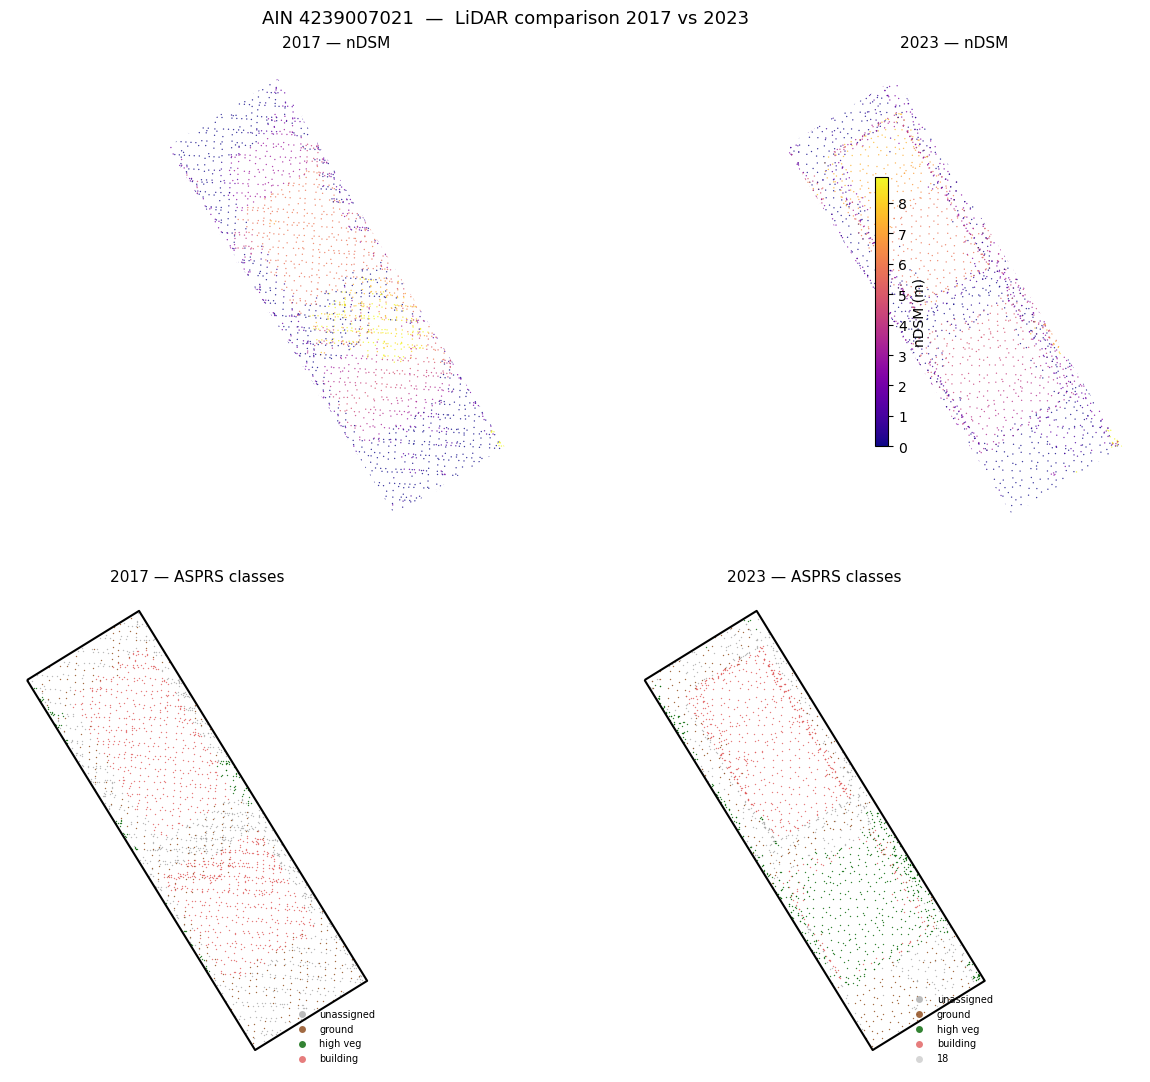

In [47]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

CLASS_COLORS = {1:'#aaaaaa', 2:'#8B4513', 3:'#90EE90',
                4:'#228B22', 5:'#006400', 6:'#e05c5c'}

epochs = list(data.keys())

# shared nDSM colour scale across both epochs
all_ndsm = np.concatenate([d['ndsm'] for d in data.values()])
vmax = float(np.nanpercentile(all_ndsm[np.isfinite(all_ndsm)], 98))
norm = Normalize(vmin=0, vmax=vmax)
cmap = plt.cm.plasma

fig, axes = plt.subplots(2, 2, figsize=(13, 11))

for col, epoch in enumerate(epochs):
    d = data[epoch]
    xyz_p, cls_p, ndsm = d['xyz_p'], d['cls_p'], d['ndsm']

    # ── row 0: nDSM heat map ──────────────────────────────────────────────────
    ax = axes[0, col]
    valid = np.isfinite(ndsm)
    ax.scatter(xyz_p[valid, 0], xyz_p[valid, 1],
               c=ndsm[valid], cmap=cmap, norm=norm,
               s=1, linewidths=0, alpha=0.8, rasterized=True)
    gpd.GeoSeries([parcel_poly], crs=UTM_CRS).boundary.plot(
        ax=ax, edgecolor='white', linewidth=1.5)
    ax.set_title(f'{epoch} — nDSM', fontsize=11)
    ax.set_aspect('equal'); ax.axis('off')

    # ── row 1: ASPRS class map ────────────────────────────────────────────────
    ax = axes[1, col]
    for c in np.unique(cls_p):
        m = cls_p == c
        ax.scatter(xyz_p[m, 0], xyz_p[m, 1],
                   c=CLASS_COLORS.get(int(c), '#cccccc'), s=1,
                   linewidths=0, alpha=0.8, rasterized=True,
                   label=CLASS_LABELS.get(int(c), str(c)))
    gpd.GeoSeries([parcel_poly], crs=UTM_CRS).boundary.plot(
        ax=ax, edgecolor='black', linewidth=1.5)
    ax.legend(loc='lower right', fontsize=7, markerscale=5, frameon=False)
    ax.set_title(f'{epoch} — ASPRS classes', fontsize=11)
    ax.set_aspect('equal'); ax.axis('off')

# shared colorbar for nDSM row
fig.colorbar(ScalarMappable(norm=norm, cmap=cmap),
             ax=axes[0, :], label='nDSM (m)', shrink=0.7)

plt.suptitle(f'AIN {AIN}  —  LiDAR comparison 2017 vs 2023', fontsize=13)
plt.tight_layout()

out = f'notebooks/tasks/figures/lidar_{AIN}_comparison.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
print(f'Saved → {out}')
plt.show()


LARIAC 2014: no buildings found in parcel
LARIAC 2017: 2 polygon(s)  →  2,446 sq ft
LARIAC 2020: 2 polygon(s)  →  2,734 sq ft
LiDAR 2017: 1,854 sq ft
LiDAR 2023: 1,259 sq ft
Saved → notebooks/tasks/figures/lidar_4239007021_sqft_timeseries.png


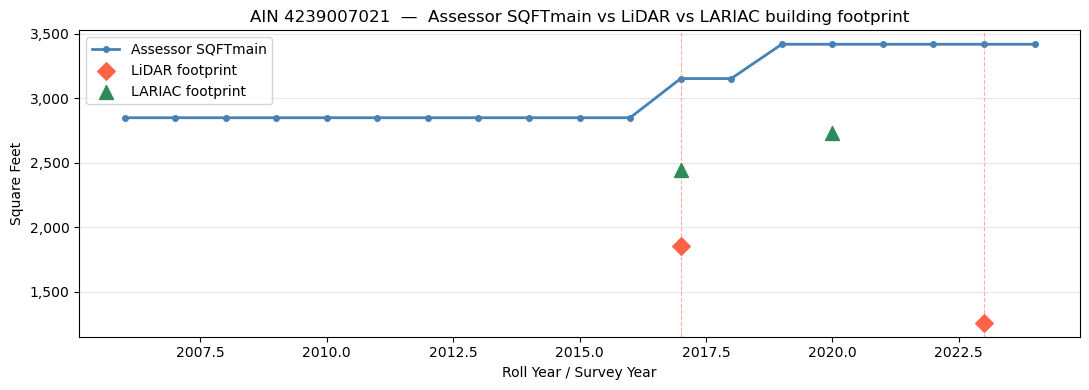

In [48]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

M2_TO_SQFT = 10.7639
GRID_RES_M = 0.5

LARIAC_FILES = {
    2014: '/Users/adamswietek/Documents/PostDoc/data/raw_la/laraic_files/LARIAC4_Buildings_2014.gdb',
    2017: '/Users/adamswietek/Documents/PostDoc/data/raw_la/laraic_files/LARIAC5_Buildings_2017.gdb',
    2020: '/Users/adamswietek/Documents/PostDoc/data/raw_la/laraic_files/LARIAC6_Buildings_2020.gdb',
}
LARIAC_LAYERS = {
    2014: 'LARIAC4_BUILDINGS_2014',
    2017: 'LARIAC5_BUILDINGS_2017',
    2020: 'LARIAC6_BUILDINGS_2020',
}

# parcel in EPSG:2229 (LARIAC native CRS — US survey feet) for spatial filter
parcel_2229 = gpd.GeoSeries([parcel_poly], crs=UTM_CRS).to_crs('EPSG:2229').iloc[0]

# ── Load LARIAC footprints for this parcel ────────────────────────────────────
lariac_data = {}
for year, path in LARIAC_FILES.items():
    layer = LARIAC_LAYERS[year]
    gdf = gpd.read_file(path, layer=layer, mask=parcel_2229)
    if not gdf.empty:
        # Shape_Area is in sq survey-ft (EPSG:2229 linear unit = US survey foot)
        area_sqft = gdf['Shape_Area'].sum()
        lariac_data[year] = {'gdf': gdf.to_crs(UTM_CRS), 'area_sqft': area_sqft}
        print(f"LARIAC {year}: {len(gdf)} polygon(s)  →  {area_sqft:,.0f} sq ft")
    else:
        print(f"LARIAC {year}: no buildings found in parcel")

# ── Assessor time series ──────────────────────────────────────────────────────
assr = (load_parcels_by_AIN([AIN])
        .dropna(subset=['SQFTmain', 'RollYear'])
        .sort_values('RollYear'))
assr = assr[assr['SQFTmain'] > 0]

# ── LiDAR footprint area per epoch (rasterise class-6 onto 0.5 m grid) ───────
LIDAR_YEARS = {'2017': 2017, '2023': 2023}
lidar_pts = {}
for epoch, d in data.items():
    bldg = d['xyz_p'][d['cls_p'] == 6, :2]
    if len(bldg) == 0:
        continue
    x_edges = np.arange(bldg[:, 0].min(), bldg[:, 0].max() + GRID_RES_M, GRID_RES_M)
    y_edges = np.arange(bldg[:, 1].min(), bldg[:, 1].max() + GRID_RES_M, GRID_RES_M)
    H, _, _ = np.histogram2d(bldg[:, 0], bldg[:, 1], bins=[x_edges, y_edges])
    area_sqft = (H > 0).sum() * GRID_RES_M**2 * M2_TO_SQFT
    lidar_pts[LIDAR_YEARS[epoch]] = area_sqft
    print(f"LiDAR {epoch}: {area_sqft:,.0f} sq ft")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(assr['RollYear'], assr['SQFTmain'],
        color='steelblue', linewidth=2, marker='o', markersize=4,
        label='Assessor SQFTmain')

first_lidar = True
for yr, sqft in lidar_pts.items():
    ax.axvline(yr, color='tomato', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.scatter(yr, sqft, color='tomato', s=80, zorder=5, marker='D',
               label='LiDAR footprint' if first_lidar else '_nolegend_')
    first_lidar = False

first_lariac = True
for yr, d in sorted(lariac_data.items()):
    ax.scatter(yr, d['area_sqft'], color='seagreen', s=100, zorder=6, marker='^',
               label='LARIAC footprint' if first_lariac else '_nolegend_')
    first_lariac = False

ax.set_xlabel('Roll Year / Survey Year')
ax.set_ylabel('Square Feet')
ax.set_title(f'AIN {AIN}  —  Assessor SQFTmain vs LiDAR vs LARIAC building footprint')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
out = f'notebooks/tasks/figures/lidar_{AIN}_sqft_timeseries.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
print(f'Saved → {out}')
plt.show()


In [ ]:
#set of buildings were no change lariac, no udu, 

In [49]:
assr[['RollYear','SQFTmain']]

,RollYear,SQFTmain
0,2006,2850
1,2007,2850
2,2008,2850
3,2009,2850
4,2010,2850
5,2011,2850
6,2012,2850
7,2013,2850
8,2014,2850
9,2015,2850


In [50]:
import pyvista as pv

pv.set_jupyter_backend('trame')   # renders inline in VS Code as a static image

epochs  = list(data.keys())
all_ndsm = np.concatenate([d['ndsm'] for d in data.values()])
clim     = [0, float(np.nanpercentile(all_ndsm[np.isfinite(all_ndsm)], 98))]

pl = pv.Plotter(shape=(1, 2), window_size=(900, 700), off_screen=False)

for col, epoch in enumerate(epochs):
    d = data[epoch]
    xyz_p, ndsm = d['xyz_p'], d['ndsm']

    # keep only points with finite nDSM
    valid = np.isfinite(ndsm)
    cloud = pv.PolyData(xyz_p[valid].astype(np.float32))
    cloud['nDSM (m)'] = ndsm[valid].astype(np.float32)

    pl.subplot(0, col)
    pl.add_points(
        cloud,
        scalars='nDSM (m)',
        clim=clim,
        cmap='plasma',
        point_size=8,
        render_points_as_spheres=False,
    )
    pl.add_title(f'LiDAR {epoch}', font_size=14)
    pl.view_xy()           # top-down view
    pl.camera.elevation = 30  # slight tilt for depth

pl.link_views()            # sync camera across both subplots
pl.show()


Widget(value='<iframe src="http://localhost:57432/index.html?ui=P_0x34b0a8e30_3&reconnect=auto" class="pyvista…

/var/folders/7b/rl6lkdns1dbfv_n3wwwmq8580000gn/T/ipykernel_79407/549890457.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved → notebooks/tasks/figures/lidar_4239007021_lariac_overlay.png


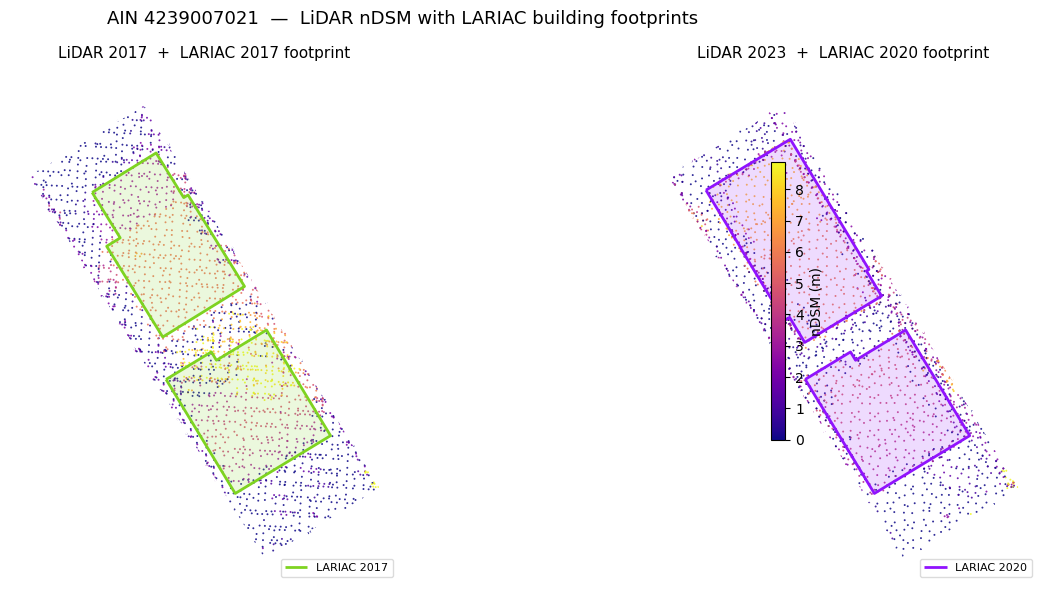

In [51]:
# ── 2D top-down LiDAR point cloud with LARIAC footprints overlaid ─────────────
# Columns: 2017 LiDAR + LARIAC5(2017)  |  2023 LiDAR + LARIAC6(2020)
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

EPOCH_LARIAC = {'2017': 2017, '2023': 2020}   # closest LARIAC survey per epoch
LARIAC_COLORS = {2014: '#f5a623', 2017: '#7ed321', 2020: '#9013fe'}

epochs = list(data.keys())
all_ndsm = np.concatenate([d['ndsm'] for d in data.values()])
vmax = float(np.nanpercentile(all_ndsm[np.isfinite(all_ndsm)], 98))
norm = Normalize(vmin=0, vmax=vmax)
cmap = plt.cm.plasma

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, epoch in zip(axes, epochs):
    d = data[epoch]
    xyz_p, ndsm = d['xyz_p'], d['ndsm']

    # point cloud coloured by nDSM
    valid = np.isfinite(ndsm)
    sc = ax.scatter(xyz_p[valid, 0], xyz_p[valid, 1],
                    c=ndsm[valid], cmap=cmap, norm=norm,
                    s=2, linewidths=0, alpha=0.85, rasterized=True)

    # parcel boundary
    gpd.GeoSeries([parcel_poly], crs=UTM_CRS).boundary.plot(
        ax=ax, edgecolor='white', linewidth=1.5, linestyle='--')

    # LARIAC footprint for the matched survey year
    lariac_yr = EPOCH_LARIAC[epoch]
    if lariac_yr in lariac_data:
        lariac_gdf = lariac_data[lariac_yr]['gdf']
        lariac_gdf.boundary.plot(
            ax=ax,
            edgecolor=LARIAC_COLORS[lariac_yr],
            linewidth=2.0,
            label=f'LARIAC {lariac_yr}',
        )
        # also fill with low opacity to make footprint easy to see
        lariac_gdf.plot(
            ax=ax,
            facecolor=LARIAC_COLORS[lariac_yr],
            alpha=0.15,
            edgecolor='none',
        )

    ax.set_title(f'LiDAR {epoch}  +  LARIAC {lariac_yr} footprint', fontsize=11)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.legend(loc='lower right', fontsize=8, frameon=True, framealpha=0.7)

fig.colorbar(ScalarMappable(norm=norm, cmap=cmap),
             ax=axes, label='nDSM (m)', shrink=0.6, pad=0.02)

plt.suptitle(f'AIN {AIN}  —  LiDAR nDSM with LARIAC building footprints', fontsize=13)
plt.tight_layout()

out = f'notebooks/tasks/figures/lidar_{AIN}_lariac_overlay.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
print(f'Saved → {out}')
plt.show()


In [52]:
import laspy as lp

# ── check bbox consistency across both sites ──────────────────────────────────
print("Parcel polygon bounds (UTM):", parcel_poly.bounds)
print()

for epoch, site in SITES.items():
    las = lp.read(site['cls_file'])
    print(f"── {epoch} ──────────────────────────────────────")
    print(f"  LAZ CRS       : {las.header.parse_crs()}")
    print(f"  LAZ x range   : {las.x.min():.1f} → {las.x.max():.1f}")
    print(f"  LAZ y range   : {las.y.min():.1f} → {las.y.max():.1f}")
    d = data[epoch]
    bldg_in = (d['cls_p'] == 6).sum()
    print(f"  pts in parcel : {len(d['xyz_p']):,}  |  class-6 building: {bldg_in:,}")
    bldg_pts = d['xyz_p'][d['cls_p'] == 6, :2]
    if len(bldg_pts):
        x_range = bldg_pts[:, 0].max() - bldg_pts[:, 0].min()
        y_range = bldg_pts[:, 1].max() - bldg_pts[:, 1].min()
        n_bins  = max(1, int((x_range + y_range) / GRID_RES_M))
        H, _, _ = np.histogram2d(bldg_pts[:, 0], bldg_pts[:, 1], bins=n_bins)
        area_sqft = (H > 0).sum() * GRID_RES_M**2 * M2_TO_SQFT
        print(f"  footprint     : {area_sqft:,.0f} sq ft")
    print()


Parcel polygon bounds (UTM): (364576.3286178863, 3762834.100620269, 364607.81348884985, 3762874.7503232467)

── 2017 ──────────────────────────────────────
  LAZ CRS       : PROJCS["WGS 84 / UTM zone 11N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32611"]]
  LAZ x range   : 364547.7 → 364636.4
  LAZ y range   : 3762800.4 → 3762908.4
  pts in parcel : 2,288  |  class-6 building: 1,017
  footprint     : 2,481 sq ft

── 2023 ──────────────────────────────────────
  LAZ CRS       : 

In [53]:
assr.columns

Index(['SitusZIP', 'TaxRateArea_CITY', 'AIN', 'RollYear', 'TaxRateArea',
       'AssessorID', 'PropertyLocation', 'UseType', 'UseCode',
       'UseCodeDescChar1', 'UseCodeDescChar2', 'UseCodeDescChar3',
       'UseCodeDescChar4', 'totBuildingDataLines', 'YearBuilt',
       'EffectiveYearBuilt', 'SQFTmain', 'Bedrooms', 'Bathrooms', 'Units',
       'RecordingDate', 'Roll_LandValue', 'Roll_LandBaseYear', 'Roll_ImpValue',
       'Roll_ImpBaseYear', 'Roll_totLandImp', 'Roll_HomeOwnersExemp',
       'Roll_RealEstateExemp', 'Roll_FixtureValue', 'Roll_FixtureExemp',
       'Roll_PersPropValue', 'Roll_PersPropExemp', 'isTaxableParcel',
       'Roll_TotalValue', 'Roll_TotalExemption', 'netTaxableValue',
       'ParcelClassification', 'AdminRegion', 'Cluster',
       'ParcelBoundaryDescription', 'SitusHouseNo', 'SitusFraction',
       'SitusDirection', 'SitusStreet', 'SitusUnit', 'SitusCity', 'SitusZIP5',
       'rowID', 'CENTER_LAT', 'CENTER_LON'],
      dtype='str')

In [54]:
assr[['UseType', 'UseCode',
       'UseCodeDescChar1', 'UseCodeDescChar2', 'UseCodeDescChar3',
       'UseCodeDescChar4']]#.drop_duplicates()

,UseType,UseCode,UseCodeDescChar1,UseCodeDescChar2,UseCodeDescChar3,UseCodeDescChar4
0,R-I,0400,Residential,Four Units (Any Combination),4 Stories or Less,
1,R-I,0400,Residential,Four Units (Any Combination),4 Stories or Less,
2,R-I,0400,Residential,Four Units (Any Combination),4 Stories or Less,
3,R-I,0400,Residential,Four Units (Any Combination),4 Stories or Less,
4,R-I,0400,Residential,Four Units (Any Combination),4 Stories or Less,
5,R-I,0400,Residential,Four Units (Any Combination),4 Stories or Less,
6,R-I,0400,Residential,Four Units (Any Combination),4 Stories or Less,
7,R-I,0400,Residential,Four Units (Any Combination),4 Stories or Less,
8,R-I,0400,Residential,Four Units (Any Combination),4 Stories or Less,
9,R-I,0400,Residential,Four Units (Any Combination),4 Stories or Less,
